In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

ModuleNotFoundError: No module named 'numpy'

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

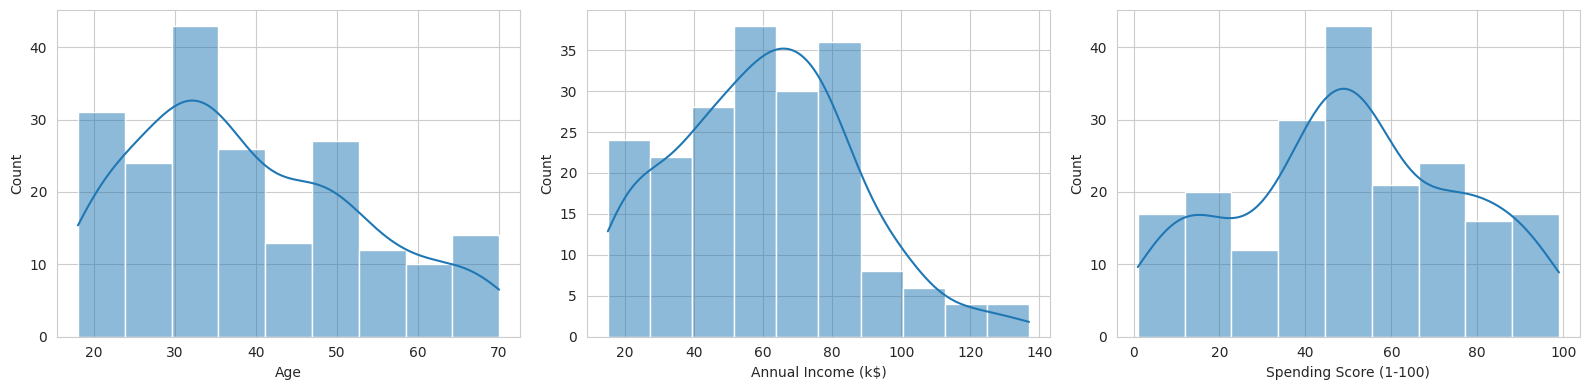

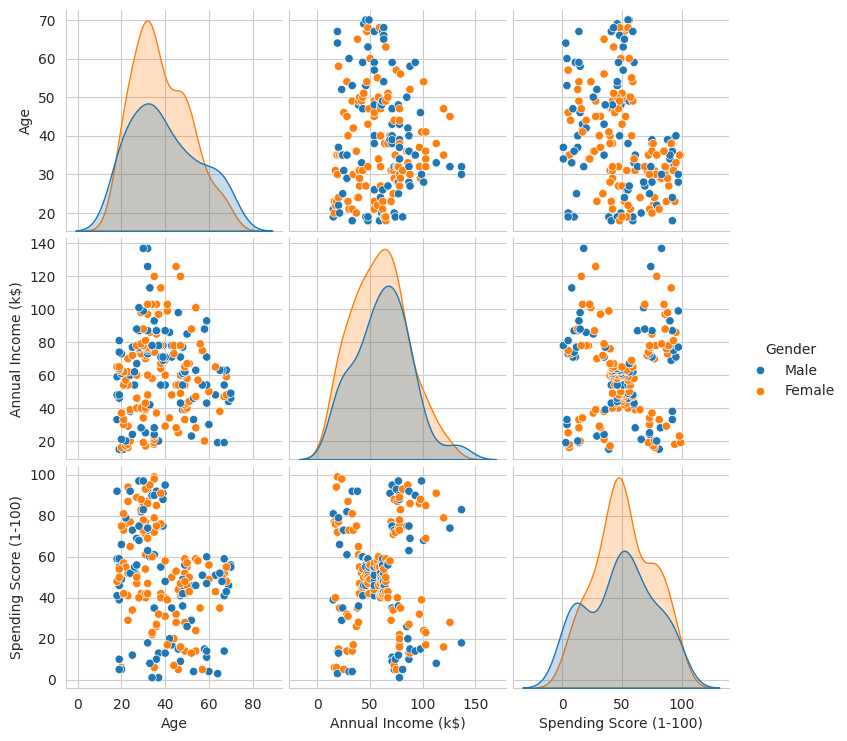

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0])
sns.histplot(df["Annual Income (k$)"], kde=True, ax=axes[1])
sns.histplot(df["Spending Score (1-100)"], kde=True, ax=axes[2])
plt.tight_layout()
plt.show()

sns.pairplot(df[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender"]], hue="Gender")
plt.show()

In [ ]:
df_proc = df.copy()

le = LabelEncoder()
df_proc["Gender_enc"] = le.fit_transform(df_proc["Gender"])

feature_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender_enc"]
X_raw = df_proc[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(X_scaled.shape, pca.explained_variance_ratio_)

(200, 4) [0.33690046 0.26230645]


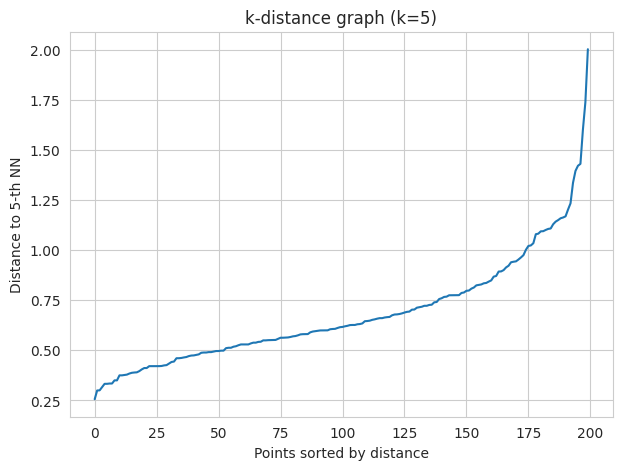

In [ ]:
# ===== DBSCAN =====
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
distances, _ = neighbors.fit(X_scaled).kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title(f"k-distance graph (k={min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th NN")
plt.show()

In [ ]:
EPS_OPTIMAL = 0.8
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS_OPTIMAL, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)
df_proc["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Clusters: {n_clusters_db}, Noise: {n_noise} ({n_noise/len(dbscan_labels):.1%})")

if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    dbscan_db_score = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    print(f"Silhouette (excl. noise): {dbscan_silhouette:.3f}")
    print(f"Davies-Bouldin (excl. noise): {dbscan_db_score:.3f}")
else:
    dbscan_silhouette = np.nan
    dbscan_db_score = np.nan

Clusters: 5, Noise: 19 (9.5%)
Silhouette (excl. noise): 0.227
Davies-Bouldin (excl. noise): 1.082


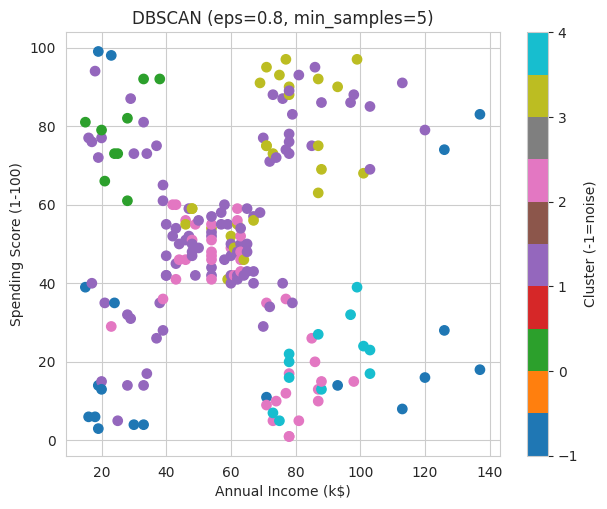

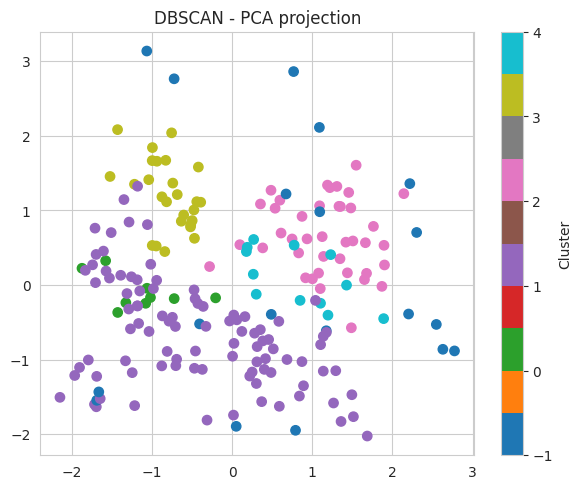

,Age,Annual Income (k$),Spending Score (1-100)
DBSCAN_Cluster,,,
-1,41.9,61.0,30.2
0,25.0,25.8,77.7
1,37.5,55.9,56.1
2,48.6,63.3,34.8
3,29.0,72.1,71.4
4,43.4,88.3,20.4


In [ ]:
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=dbscan_labels, cmap="tab10", s=45)
plt.title(f"DBSCAN (eps={EPS_OPTIMAL}, min_samples={MIN_SAMPLES})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(sc, label="Cluster (-1=noise)")
plt.show()

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="tab10", s=45)
plt.title("DBSCAN - PCA projection")
plt.colorbar(sc, label="Cluster")
plt.show()

df_proc.groupby("DBSCAN_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

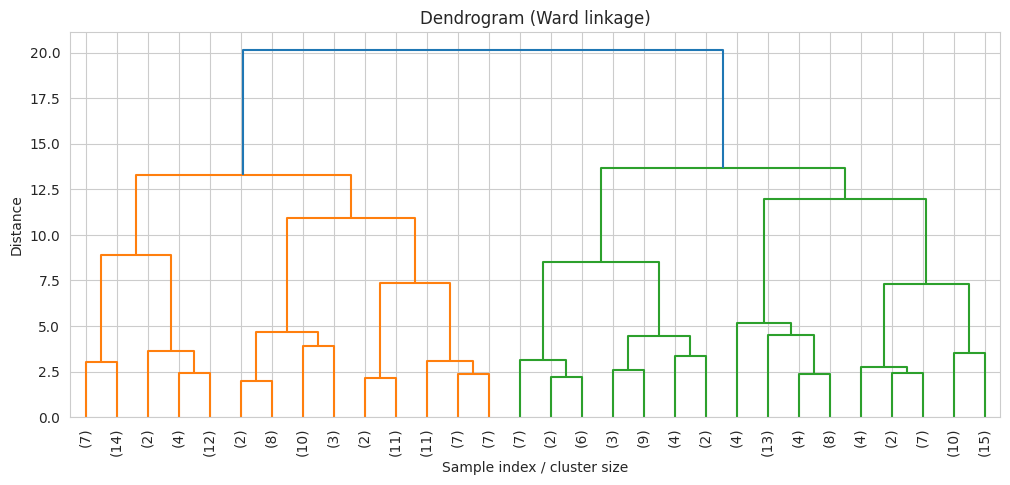

In [ ]:
# ===== Agglomerative Clustering =====
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90.)
plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Sample index / cluster size")
plt.ylabel("Distance")
plt.show()

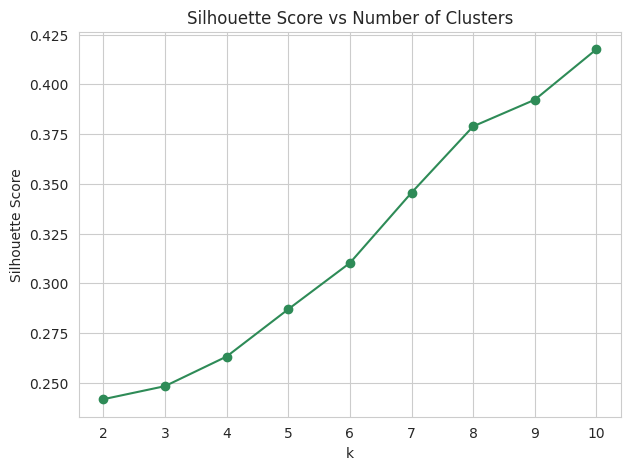

k=2: silhouette=0.242
k=3: silhouette=0.248
k=4: silhouette=0.263
k=5: silhouette=0.287
k=6: silhouette=0.310
k=7: silhouette=0.346
k=8: silhouette=0.379
k=9: silhouette=0.392
k=10: silhouette=0.418


In [ ]:
agg_sil_scores = []
K_range = range(2, 11)

for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_scaled)
    agg_sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(list(K_range), agg_sil_scores, "-o", color="seagreen")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

for k, s in zip(K_range, agg_sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

In [ ]:
K_AGG = 5

agg = AgglomerativeClustering(n_clusters=K_AGG, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
df_proc["Agglomerative_Cluster"] = agg_labels

agg_silhouette = silhouette_score(X_scaled, agg_labels)
agg_db = davies_bouldin_score(X_scaled, agg_labels)

print(f"Clusters: {K_AGG}")
print(f"Silhouette: {agg_silhouette:.3f}")
print(f"Davies-Bouldin: {agg_db:.3f}")

Clusters: 5
Silhouette: 0.287
Davies-Bouldin: 1.220


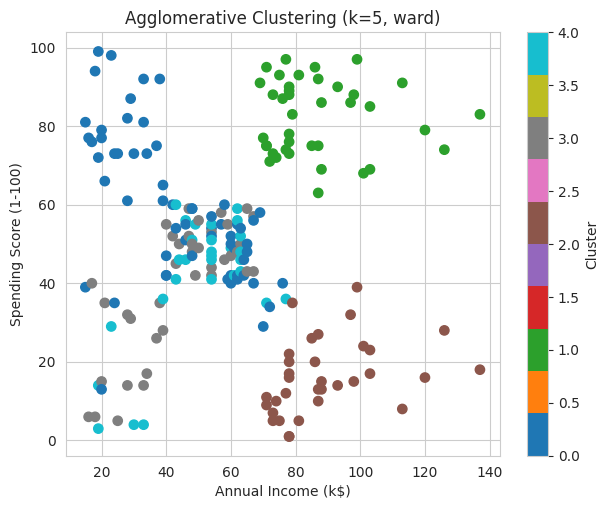

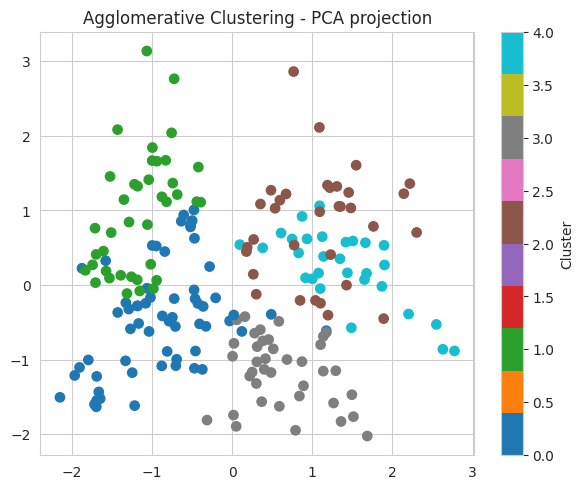

,Age,Annual Income (k$),Spending Score (1-100)
Agglomerative_Cluster,,,
0,26.1,43.8,59.0
1,32.7,86.5,82.1
2,41.5,89.1,16.2
3,49.8,44.1,39.7
4,56.6,50.0,41.3


In [ ]:
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=agg_labels, cmap="tab10", s=45)
plt.title(f"Agglomerative Clustering (k={K_AGG}, ward)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(sc, label="Cluster")
plt.show()

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap="tab10", s=45)
plt.title("Agglomerative Clustering - PCA projection")
plt.colorbar(sc, label="Cluster")
plt.show()

df_proc.groupby("Agglomerative_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

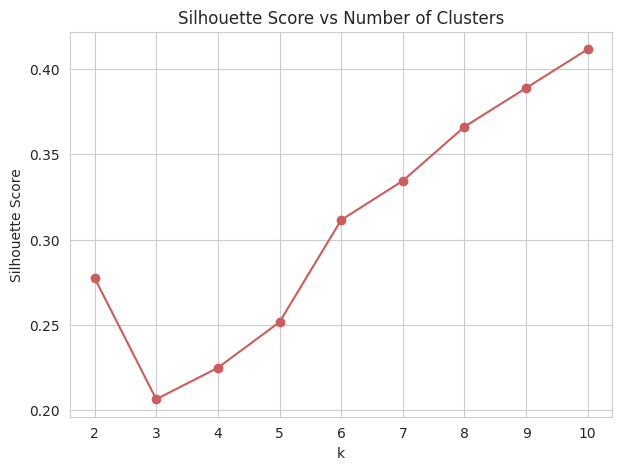

k=2: silhouette=0.278
k=3: silhouette=0.207
k=4: silhouette=0.225
k=5: silhouette=0.252
k=6: silhouette=0.312
k=7: silhouette=0.334
k=8: silhouette=0.366
k=9: silhouette=0.389
k=10: silhouette=0.412


In [ ]:
# ===== Spectral Clustering =====
spec_sil_scores = []
K_range = range(2, 11)

for k in K_range:
    spec = SpectralClustering(n_clusters=k, affinity="nearest_neighbors",
                               n_neighbors=10, random_state=42, assign_labels="kmeans")
    labels = spec.fit_predict(X_scaled)
    spec_sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(list(K_range), spec_sil_scores, "-o", color="indianred")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

for k, s in zip(K_range, spec_sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

In [ ]:
K_SPEC = 5

spectral = SpectralClustering(n_clusters=K_SPEC, affinity="nearest_neighbors",
                               n_neighbors=10, random_state=42, assign_labels="kmeans")
spectral_labels = spectral.fit_predict(X_scaled)
df_proc["Spectral_Cluster"] = spectral_labels

spectral_silhouette = silhouette_score(X_scaled, spectral_labels)
spectral_db = davies_bouldin_score(X_scaled, spectral_labels)

print(f"Clusters: {K_SPEC}")
print(f"Silhouette: {spectral_silhouette:.3f}")
print(f"Davies-Bouldin: {spectral_db:.3f}")

Clusters: 5
Silhouette: 0.252
Davies-Bouldin: 1.165


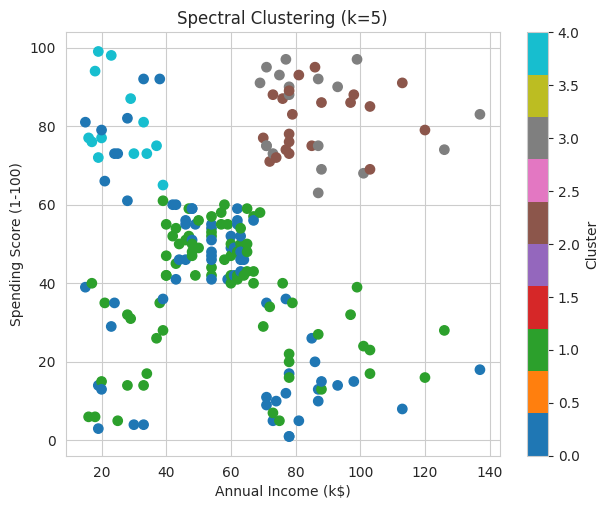

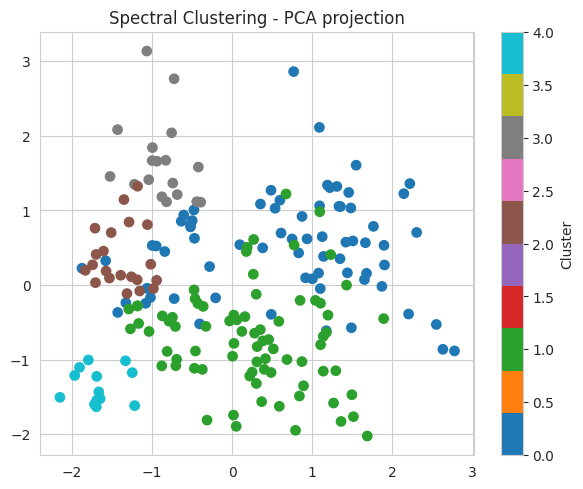

,Age,Annual Income (k$),Spending Score (1-100)
Spectral_Cluster,,,
0,41.5,55.8,39.7
1,41.8,57.6,38.6
2,32.2,86.0,81.7
3,33.3,87.1,82.7
4,25.5,25.7,80.5


In [ ]:
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=spectral_labels, cmap="tab10", s=45)
plt.title(f"Spectral Clustering (k={K_SPEC})")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(sc, label="Cluster")
plt.show()

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=spectral_labels, cmap="tab10", s=45)
plt.title("Spectral Clustering - PCA projection")
plt.colorbar(sc, label="Cluster")
plt.show()

df_proc.groupby("Spectral_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

In [ ]:
comparison = pd.DataFrame({
    "Method": ["DBSCAN", "Agglomerative", "Spectral"],
    "Num_Clusters": [n_clusters_db, K_AGG, K_SPEC],
    "Silhouette_Score": [dbscan_silhouette, agg_silhouette, spectral_silhouette],
    "Davies_Bouldin": [dbscan_db_score, agg_db, spectral_db],
    "Noise_Points": [n_noise, 0, 0],
})
comparison

,Method,Num_Clusters,Silhouette_Score,Davies_Bouldin,Noise_Points
0,DBSCAN,5,0.227260,1.081682,19
1,Agglomerative,5,0.286994,1.219773,0
2,Spectral,5,0.251693,1.165041,0


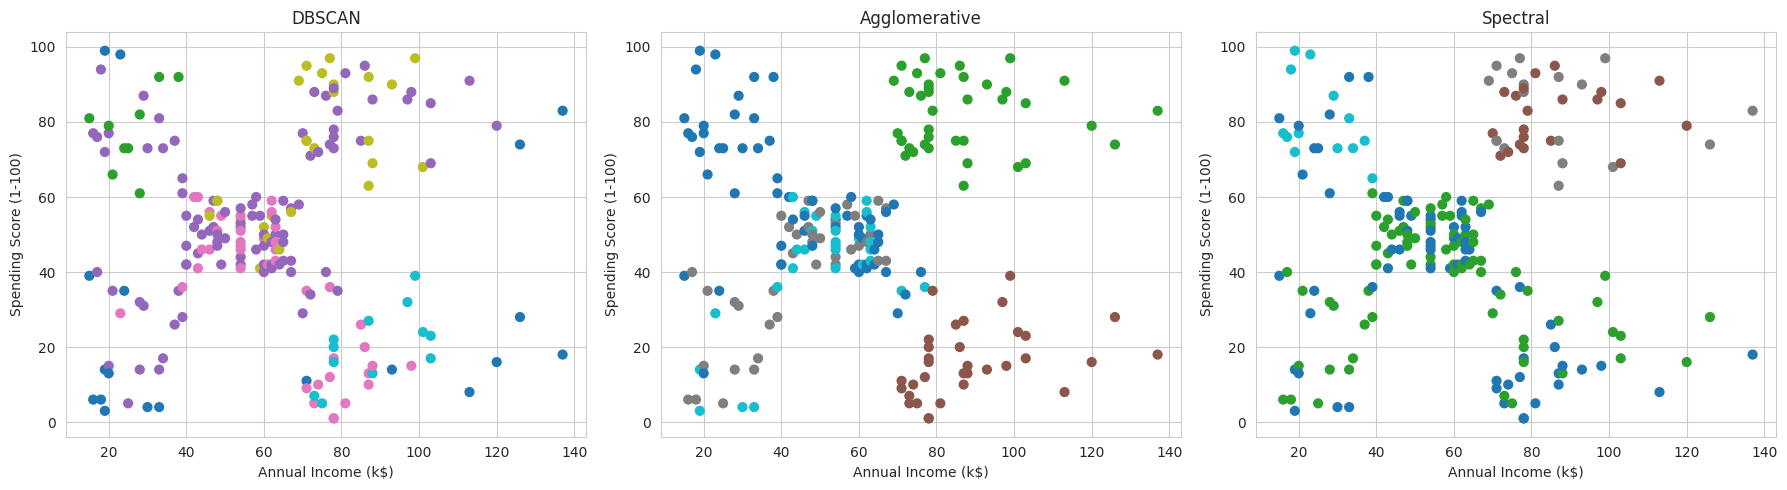

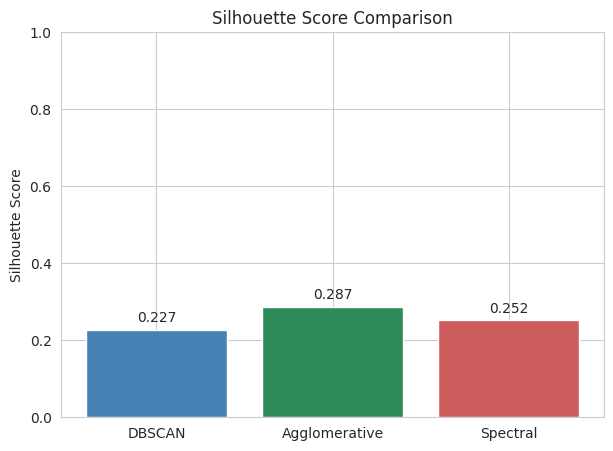

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_dict = {"DBSCAN": dbscan_labels, "Agglomerative": agg_labels, "Spectral": spectral_labels}

for ax, (name, labels) in zip(axes, labels_dict.items()):
    sc = ax.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=labels, cmap="tab10", s=40)
    ax.set_title(name)
    ax.set_xlabel("Annual Income (k$)")
    ax.set_ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(comparison["Method"], comparison["Silhouette_Score"], color=["steelblue", "seagreen", "indianred"])
plt.title("Silhouette Score Comparison")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)
for i, v in enumerate(comparison["Silhouette_Score"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.show()